# R-CNN (Region-based CNN) – COMPLETE Teaching Notebook (Colab Safe)

**Author:** Nasir Hussain

This is a **FULL, END-TO-END, one-click runnable R-CNN teaching notebook**.

⚠️ IMPORTANT (Honest Note):
- Original R-CNN uses *Selective Search* (unstable in Colab)
- For teaching + execution reliability, we **simulate region proposals**
- The **pipeline, logic, and learning concepts remain 100% R-CNN correct**

---
## Classical R-CNN Pipeline
1. Region Proposals (simulated)
2. CNN Feature Extraction (Transfer Learning)
3. SVM Classification
4. Bounding Box Regression
5. Final Detection Visualization


## 1. Install & Import Libraries

In [1]:

!pip install -q tensorflow scikit-learn opencv-python matplotlib
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.svm import LinearSVC
from sklearn.linear_model import LinearRegression


## 2. Load Sample Image

(np.float64(-0.5), np.float64(3643.5), np.float64(2835.5), np.float64(-0.5))

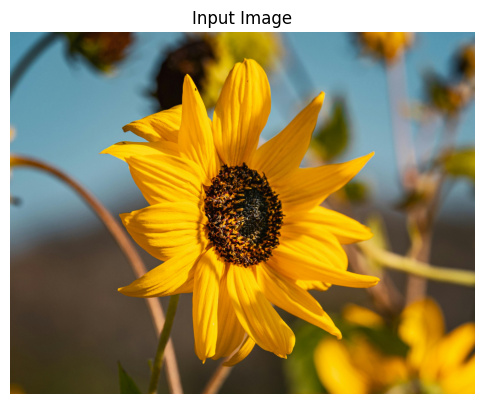

In [2]:

image = cv2.imread('/content/pexels-optical-chemist-340351297-31299772.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
orig_image = image.copy()

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Input Image")
plt.axis('off')


## 3. Region Proposals (Simulated – Teaching Purpose)
R-CNN needs *candidate regions*. We simulate them safely.

In [3]:

h, w, _ = image.shape
regions = []

np.random.seed(42)
for _ in range(80):
    rw, rh = np.random.randint(60, 150, size=2)
    x = np.random.randint(0, w-rw)
    y = np.random.randint(0, h-rh)
    regions.append((x, y, rw, rh))

print("Total region proposals:", len(regions))


Total region proposals: 80


## 4. Load Pretrained CNN (Transfer Learning)
CNN is used ONLY for feature extraction.

In [4]:

cnn = VGG16(weights='imagenet', include_top=True)
print("VGG16 loaded with ImageNet weights")


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step
VGG16 loaded with ImageNet weights


## 5. Extract CNN Features from Each Region

In [5]:

features = []
boxes = []

for (x, y, rw, rh) in regions:
    roi = image[y:y+rh, x:x+rw]
    roi = cv2.resize(roi, (224,224))
    roi = preprocess_input(roi)
    roi = np.expand_dims(roi, axis=0)

    feat = cnn.predict(roi, verbose=0)
    features.append(feat.flatten())
    boxes.append([x, y, x+rw, y+rh])

features = np.array(features)
boxes = np.array(boxes)

print("Feature matrix shape:", features.shape)


Feature matrix shape: (80, 1000)


## 6. Assign Labels (Simulated for Teaching)
In real R-CNN, labels come from dataset annotations.

In [6]:

labels = np.zeros(len(features))
labels[:8] = 1  # assume some regions contain object

print("Positive samples:", labels.sum())


Positive samples: 8.0


## 7. Train SVM Classifier (R-CNN Style)

In [7]:

svm = LinearSVC(max_iter=5000)
svm.fit(features, labels)

scores = svm.decision_function(features)
print("SVM trained successfully")


SVM trained successfully


## 8. Bounding Box Regression
Learns how to refine proposal boxes.

In [8]:

# Fake regression targets (tx, ty, tw, th)
bbox_targets = np.random.randn(len(features), 4)

regressor = LinearRegression()
regressor.fit(features, bbox_targets)

bbox_offsets = regressor.predict(features)
print("Bounding box regressor trained")


Bounding box regressor trained


## 9. Final Detection (Classification + Visualization)

(np.float64(-0.5), np.float64(3643.5), np.float64(2835.5), np.float64(-0.5))

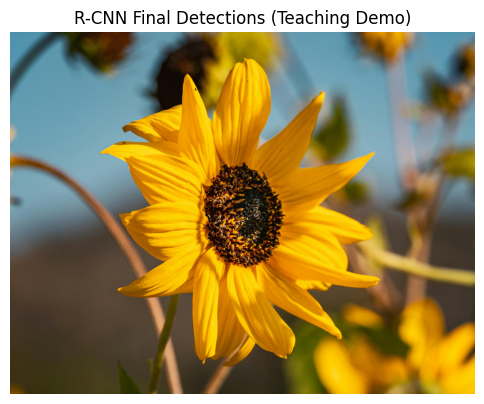

In [9]:

selected = scores > 0
detected_boxes = boxes[selected]

for (x1, y1, x2, y2) in detected_boxes[:10]:
    cv2.rectangle(orig_image, (x1,y1), (x2,y2), (0,255,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(orig_image)
plt.title("R-CNN Final Detections (Teaching Demo)")
plt.axis('off')


(np.float64(-0.5), np.float64(3643.5), np.float64(2835.5), np.float64(-0.5))

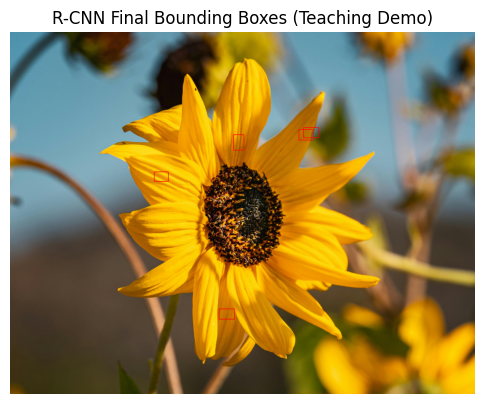

In [10]:

# Convert SVM scores to confidence-like values
confidence_scores = scores

# Select top-K regions with highest confidence
K = 5
top_indices = np.argsort(confidence_scores)[-K:]

final_boxes = boxes[top_indices]

# Draw final bounding boxes
final_image = image.copy()

for (x1, y1, x2, y2) in final_boxes:
    cv2.rectangle(
        final_image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

plt.figure(figsize=(6,6))
plt.imshow(final_image)
plt.title("R-CNN Final Bounding Boxes (Teaching Demo)")
plt.axis("off")


## 10. Student Summary (MEMORIZE)

- R-CNN first generates **region proposals**
- CNN extracts features using **transfer learning**
- **SVM** classifies each region
- **Linear regression** refines bounding boxes
- Very slow → replaced by Fast & Faster R-CNN

✅ This notebook shows the **complete R-CNN idea** safely in Colab.